# Deep Learning for Sentiment Analysis: Recurrent vs. Attention Architectures

This notebook outlines a complete deep learning pipeline for analyzing text sentiment, comparing the two dominant eras of neural NLP: Recurrent Neural Networks (**BiLSTM**) and Attention-Based Transformers (**DistilBERT**).

The workflow is broken down into four main stages:

* **Text Preprocessing:** Cleaning noise and preserving emotional tokens (emojis, emoticons, e.t.c).

* **Feature Extraction:** Comparing Word-level tokenization (static embeddings) against Subword tokenization (contextual embeddings).\

* **Model Evaluation:** Training and evaluating BiLSTM and DistilBERT architectures.

* **Visual Diagnostics & Error Analysis:** Visualizing training curves, confusion matrices, and reviewing misclassified examples.


> **Note** To execute this notebook efficiently, please ensure the runtime hardware accelerator is set to **T4 GPU**.

## 1. Setup and Imports

In [1]:
# Install required libraries
!pip install -q transformers emoji emot

import os
import re
import emoji
import random
from emot.emo_unicode import EMOTICONS_EMO

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments

# Global configurations
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid")

In [2]:
def set_global_seed(seed):
    """
    Forces all randomized operations to be fully deterministic.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    #Set TensorFlow random seed (For BiLSTM)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism() # Forces GPU math to be exact

    # Set PyTorch random seed (For DistilBERT)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Execute the lockdown
set_global_seed(1)

## 2. Pipeline Architecture


### 2.1. Text Preprocessing

The `preprocess_sentiment` function prepares text for neural networks by stripping structural noise (URLs, mentions) while deliberately preserving emotional context (emojis, emoticons, and capitalized words).

In [3]:
def preprocess_sentiment(text):
    """
    Preprocess text for neural sentiment models
    """
    # Safety check to prevent crashes on empty/NaN rows in the dataset
    if not isinstance(text, str):
        return ""

    # Change backticks to standard apostrophes
    text = text.replace("`", "'")

    # Convert standalone '@' to 'at' (e.g., "meet me @ 8")
    text = re.sub(r'(?:\s|^)@(?:\s|$)', ' at ', text)

    # Replace mentions and URLs with structural tokens
    text = re.sub(r"http\S+|www\S+|https\S+", ' urltoken ', text)
    text = re.sub(r'\@\w+', ' usertoken ', text)

    # Translate emoticons (<3 -> love)
    # Replaces spaces in the description with underscores
    for emot_char, emot_desc in EMOTICONS_EMO.items():
        if emot_char in text:
            tokenized_desc = "_".join(emot_desc.replace(",", "").split())
            text = text.replace(emot_char, f" {tokenized_desc} ")

    # Translate emojis (🔥 -> fire)
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Tag hashtags (prefix with 'hashtag')
    text = re.sub(r'#(\w+)', r' hashtag \1 ', text)

    # Tag ALL CAPS words (prefix with 'allcaps')
    text = re.sub(r'\b[A-Z]{2,}\b', lambda m: f" allcaps {m.group(0).lower()} ", text)

    # Lowercase all text
    text = text.lower()

    # Preserve emotional punctuation and censored profanity
    text = re.sub(r'\*{2,}', ' censoredswear ', text)
    text = re.sub(r'!+', ' exclamationmark ', text)
    text = re.sub(r'\?+', ' questionmark ', text)

    # Strip remaining punctuation
    # EXCEPT apostrophes (contractions) & underscores (emojis/emoticons)
    text = re.sub(r'[^\w\s\'_]', ' ', text)

    # Clean up extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### 2.2. Feature Extraction

Text data is converted into numerical tensors using two distinct strategies:

* **Word-level** sequences (for the BiLSTM)

* **Subword** Attention Masks (for DistilBERT)

In [4]:
# Word-Level Tokenization
def extract_bilstm_features(train_texts, val_texts, test_texts, max_vocab=20000, max_len=50):
    """
    Fits a word-level tokenizer for the BiLSTM, converts text to sequences,
    and applies post-padding/truncation to ensure uniform tensor shapes.

    Args:
        train_texts (list or pd.Series): Raw text strings for training.
        val_texts (list or pd.Series): Raw text strings for validation.
        test_texts (list or pd.Series): Raw text strings for testing.
        max_vocab (int): Maximum number of unique words to keep in the vocabulary.
        max_len (int): The exact length every sequence will be padded/truncated to.

    Returns:
        bilstm_tokenizer (Tokenizer): The fitted Keras Tokenizer object (contains word index).
        train_padded (numpy.ndarray): 2D array of padded integer sequences for training.
        val_padded (numpy.ndarray): 2D array of padded integer sequences for validation.
        test_padded (numpy.ndarray): 2D array of padded integer sequences for testing.
    """

    # Initialize Word-Level Tokenizer with OOV token to preserve structure
    bilstm_tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
    bilstm_tokenizer.fit_on_texts(train_texts)

    # Convert strings to integer sequences
    train_seq = bilstm_tokenizer.texts_to_sequences(train_texts)
    val_seq = bilstm_tokenizer.texts_to_sequences(val_texts)
    test_seq = bilstm_tokenizer.texts_to_sequences(test_texts)

    # Pad sequences (post-padding ensures the LSTM reads real words first)
    train_padded = pad_sequences(
        train_seq, maxlen=max_len, padding='post', truncating='post')
    val_padded = pad_sequences(
        val_seq, maxlen=max_len, padding='post', truncating='post')
    test_padded = pad_sequences(
        test_seq, maxlen=max_len, padding='post', truncating='post')

    return bilstm_tokenizer, train_padded, val_padded, test_padded


# Subword Tokenization
def extract_distilbert_features(train_texts, val_texts, test_texts, max_len=50):
    """
    Uses HuggingFace's pretrained WordPiece tokenizer.
    Outputs PyTorch tensors ('pt') for the Transformer architecture.

    Args:
        train_texts (list or pd.Series): Raw text strings for training.
        val_texts (list or pd.Series): Raw text strings for validation.
        test_texts (list or pd.Series): Raw text strings for testing.
        max_len (int): The exact length every sequence will be padded/truncated to.

    Returns:
        bert_tokenizer (DistilBertTokenizer): The pretrained HuggingFace tokenizer.
        train_encodings (dict): Contains 'input_ids' and 'attention_mask' TensorFlow tensors for training.
        val_encodings (dict): Contains 'input_ids' and 'attention_mask' TensorFlow tensors for validation.
        test_encodings (dict): Contains 'input_ids' and 'attention_mask' TensorFlow tensors for testing.
    """

    # Load the pretrained subword tokenizer matching the model
    bert_tokenizer = DistilBertTokenizer.from_pretrained(
        'distilbert-base-uncased')

    def tokenize_for_bert(texts):
        # Convert pandas series to list if necessary
        text_list = texts.tolist() if hasattr(texts, 'tolist') else texts

        # Tokenize returning PyTorch tensors ('pt')
        return bert_tokenizer(
            text_list,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )

    train_encodings = tokenize_for_bert(train_texts)
    val_encodings = tokenize_for_bert(val_texts)
    test_encodings = tokenize_for_bert(test_texts)

    return bert_tokenizer, train_encodings, val_encodings, test_encodings

### 2.3. Model Definitions

Two neural architectures are defined:

* A Bidirectional LSTM (recurrent context)

* A fine-tuned DistilBERT model (attention-based context)

Both utilize Early Stopping for regularization.

In [5]:
def evaluate_predictions(y_true, y_pred):
    """
    Calculates core classification metrics using weighted averaging
    to account for potential class imbalances in sentiment labels.
    """
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }


def get_misclassified_examples(
        y_true, y_pred, raw_texts, label_encoder, num_examples=5):
    """
    Identifies and extracts examples where the model's prediction failed.
    """
    errors_df = pd.DataFrame({
        'Text': raw_texts,
        'True_Label': label_encoder.inverse_transform(y_true),
        'Predicted_Label': label_encoder.inverse_transform(y_pred)
    })

    errors_df = errors_df[
        errors_df['True_Label'] != errors_df['Predicted_Label']]

    return errors_df.head(num_examples)


def train_bilstm(X_train, y_train, X_val, y_val, vocab_size, num_classes=3):
    """
    Builds and trains a Bidirectional LSTM with a trainable embedding layer.
    Applies Dropout and Early Stopping for regularization.

    Args:
        vocab_size (int): Maximum number of unique words kept in the vocabulary.
        max_len (int): The exact length every sequence is padded/truncated to.
        num_classes (int): The number of output sentiment categories.
    """
    print("\n--- Training BiLSTM ---")

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=64,
        callbacks=[early_stop]
    )

    # Predict and Evaluate
    print("\nEvaluating BiLSTM on Validation Set...")
    val_probs = model.predict(X_val)
    # Convert probabilities to class labels
    val_predictions = np.argmax(val_probs, axis=1)
    metrics = evaluate_predictions(y_val, val_predictions)

    return model, history, metrics, val_predictions


# PyTorch requires a Dataset object to handle batching memory efficiently
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach()
                for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


class KerasMockHistory:
    def __init__(self, logs):
        self.history = {
            'loss': [log_entry['loss'] for log_entry in logs if 'loss' in log_entry],
            'val_loss': [log_entry['eval_loss'] for log_entry in logs if 'eval_loss' in log_entry],
            'accuracy': [log_entry['eval_accuracy'] for log_entry in logs if 'eval_accuracy' in log_entry],
            'val_accuracy': [log_entry['eval_accuracy'] for log_entry in logs if 'eval_accuracy' in log_entry]
        }


def train_distilbert(train_encodings, y_train, val_encodings, y_val, num_classes=3):
    """
    Loads and fine-tunes a pretrained DistilBERT sequence classifier.
    Requires a very low learning rate to prevent catastrophic forgetting.

    Args:
        num_classes (int): The number of output sentiment categories.
    """
    print("\n--- Training DistilBERT ---")

    # Convert data into PyTorch Datasets
    train_dataset = SentimentDataset(train_encodings, y_train)
    val_dataset = SentimentDataset(val_encodings, y_val)

    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_classes
    )

    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=3e-5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True
    )

    # How trainer calculates accuracy during training
    def compute_metrics(pred):
        labels = pred.label_ids
        preds = np.argmax(pred.predictions, axis=1)
        return {'accuracy': accuracy_score(labels, preds)}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Predict and Evaluate
    print("\nEvaluating DistilBERT on Validation Set...")
    val_raw_output = trainer.predict(val_dataset)
    val_predictions = np.argmax(val_raw_output.predictions, axis=1)
    metrics = evaluate_predictions(y_val, val_predictions)
    history = KerasMockHistory(trainer.state.log_history)

    return model, history, metrics, val_predictions

## 3. Pipeline Execution

### 3.1. Data Loading

Data is loaded directly from the remote repository. A stratified split generated the train/validation set required for neural network monitoring.

In [6]:
TRAIN_URL = "https://raw.githubusercontent.com/Daniel-Ope06/sentiment-analysis/main/data2/train.csv"
VAL_URL = "https://raw.githubusercontent.com/Daniel-Ope06/sentiment-analysis/main/data2/val.csv"
TEST_URL = "https://raw.githubusercontent.com/Daniel-Ope06/sentiment-analysis/main/data2/test.csv"

df_train = pd.read_csv(TRAIN_URL, encoding='utf-8-sig').dropna(subset=['text', 'sentiment'])
df_val = pd.read_csv(VAL_URL, encoding='utf-8-sig').dropna(subset=['text', 'sentiment'])
df_test = pd.read_csv(TEST_URL, encoding='latin-1').dropna(subset=['text', 'sentiment'])

# Isolate columns and drop nulls
df_train = df_train[['text', 'sentiment']].dropna(subset=['text', 'sentiment'])
df_val = df_val[['text', 'sentiment']].dropna(subset=['text', 'sentiment'])
df_test = df_test[['text', 'sentiment']].dropna(subset=['text', 'sentiment'])

# Enforce string data type for text columns
df_train['text'] = df_train['text'].astype(str)
df_val['text'] = df_val['text'].astype(str)
df_test['text'] = df_test['text'].astype(str)

print(f"Train size: {len(df_train)} | Val size: {len(df_val)} | Test size: {len(df_test)}")

Train size: 23357 | Val size: 4123 | Test size: 3534


In [7]:
display(df_train.head())

,text,sentiment
0,Just updated #Tweetie and open in browser is still broken.,negative
1,Okay so I`m dedicating my 300th tweet to the fact that I`m going to the Apple store because there is a HUGE crack on the glass screen!,neutral
2,looks like yet another beautiful day in London,positive
3,A thursday. Is that REALLY necessary ? Have u ever heard of school and horrible mums,negative
4,about to rehearse...starving!!!,negative


### 3.2. Preprocessing Application

In [8]:
df_train['clean_text'] = df_train['text'].apply(preprocess_sentiment)
df_val['clean_text'] = df_val['text'].apply(preprocess_sentiment)
df_test['clean_text'] = df_test['text'].apply(preprocess_sentiment)

In [9]:
display(df_train[['sentiment', 'text', 'clean_text']].head())

,sentiment,text,clean_text
0,negative,Just updated #Tweetie and open in browser is still broken.,just updated hashtag tweetie and open in browser is still broken
1,neutral,Okay so I`m dedicating my 300th tweet to the fact that I`m going to the Apple store because there is a HUGE crack on the glass screen!,okay so i'm dedicating my 300th tweet to the fact that i'm going to the apple store because there is a allcaps huge crack on the glass screen exclamationmark
2,positive,looks like yet another beautiful day in London,looks like yet another beautiful day in london
3,negative,A thursday. Is that REALLY necessary ? Have u ever heard of school and horrible mums,a thursday is that allcaps really necessary questionmark have u ever heard of school and horrible mums
4,negative,about to rehearse...starving!!!,about to rehearse starving exclamationmark


### 3.3. Feature Extraction

In [ ]:
VOCAB_LIMIT = 20000
MAX_LEN = 50

# Model 1: Extract BiLSTM Features (Word-level tokenization)
bilstm_tokenizer, X_train_bilstm, X_val_bilstm, X_test_bilstm = extract_bilstm_features(
    df_train['clean_text'], df_val['clean_text'], df_test['clean_text'],
    max_vocab=VOCAB_LIMIT, max_len=MAX_LEN
)
print(f"[BiLSTM] Train Tensors Shape: {X_train_bilstm.shape}")

# Model 2: Extract DistilBERT Features (Subword tokenization)
bert_tokenizer, train_encodings, val_encodings, test_encodings = extract_distilbert_features(
    df_train['clean_text'], df_val['clean_text'], df_test['clean_text'],
    max_len=MAX_LEN
)
print(f"[DistilBERT] Train Tensors Shape: {train_encodings['input_ids'].shape}")

### 3.4. Model Training & Evaluation

In [ ]:
# Label Encoding (e.g., negative -> 0, neutral -> 1, positive -> 2)
le = LabelEncoder()
y_train = le.fit_transform(df_train['sentiment'])
y_val = le.transform(df_val['sentiment'])
y_test = le.transform(df_test['sentiment'])
NUM_CLASSES = len(le.classes_)

# Combination 1: BiLSTM + Word-Level
bilstm_model, bilstm_history, bilstm_val_metrics, _ = train_bilstm(
    X_train_bilstm, y_train, X_val_bilstm, y_val,
    vocab_size=VOCAB_LIMIT, num_classes=NUM_CLASSES
)

# Combination 2: DistilBERT + Subword
distilbert_model, bert_history, bert_val_metrics, _ = train_distilbert(
    train_encodings, y_train, val_encodings, y_val,
    num_classes=NUM_CLASSES
)

In [ ]:
# Predict and evaluate BiLSTM on strictly unseen test data
bilstm_test_probs = bilstm_model.predict(X_test_bilstm)
bilstm_test_preds = np.argmax(bilstm_test_probs, axis=1)
bilstm_test_metrics = evaluate_predictions(y_test, bilstm_test_preds)

# Predict and evaluate DistilBERT on strictly unseen test data
test_dataset = SentimentDataset(test_encodings, y_test)
inference_trainer = Trainer(model=distilbert_model)

bert_test_output = inference_trainer.predict(test_dataset)
bert_test_preds = np.argmax(bert_test_output.predictions, axis=1)
bert_test_metrics = evaluate_predictions(y_test, bert_test_preds)

# Aggregate metrics into a DataFrame for clean reporting
results_data = [
    {"Model": "BiLSTM (Word-Level)", **bilstm_test_metrics},
    {"Model": "DistilBERT (Subword)", **bert_test_metrics}
]
results_df = pd.DataFrame(results_data)

In [13]:
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,BiLSTM (Word-Level),0.712507,0.713687,0.712507,0.712718
1,DistilBERT (Subword),0.785512,0.790891,0.785512,0.786197


## 4. Visual Diagnostics & Error Analysis

### 4.1. Performance Comparison

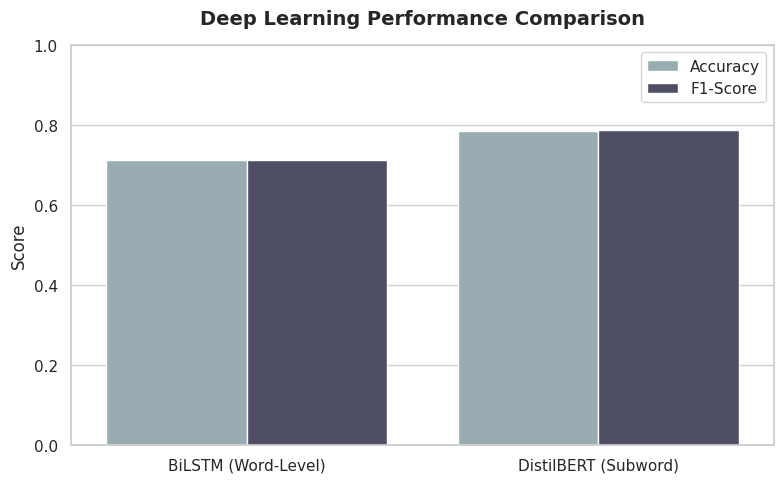

In [14]:
df_filtered = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_filtered = df_filtered[df_filtered["Metric"].isin(["Accuracy", "F1-Score"])]

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_filtered, palette="bone_r")
plt.title("Deep Learning Performance Comparison", fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.2. Training History (Learning Curves)

In [15]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#18222d', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#5a87a1', linewidth=2)
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss Plot
    ax2.plot(history.history['loss'], label='Train Loss', color='#18222d', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='#5a87a1', linewidth=2)
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

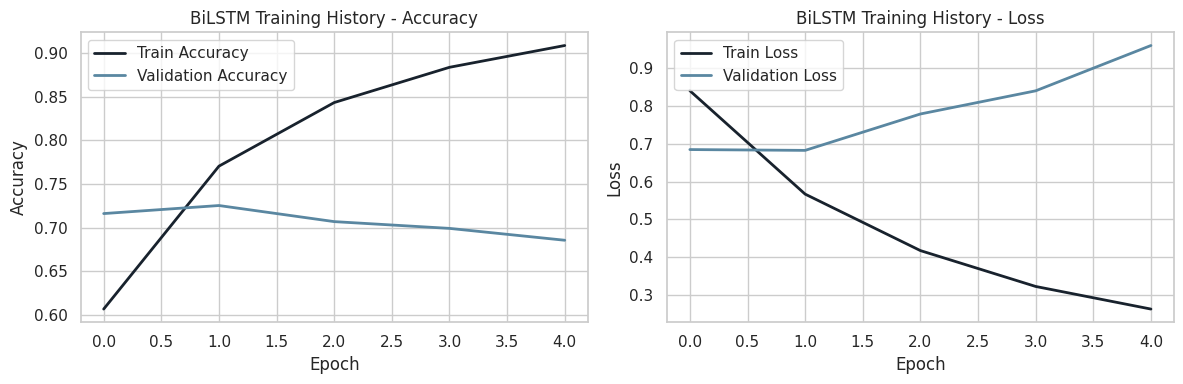

In [16]:
plot_history(bilstm_history, "BiLSTM Training History")

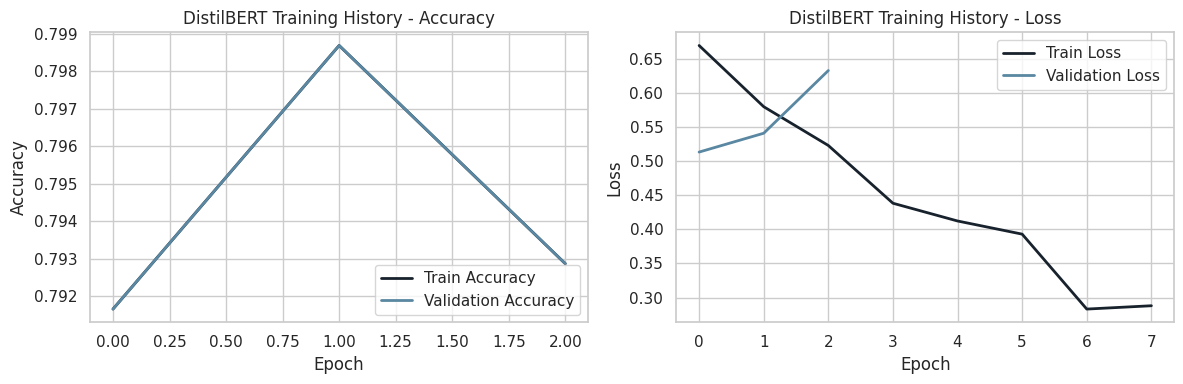

In [17]:
plot_history(bert_history, "DistilBERT Training History")

### 4.3. Confusion Matrix (DistilBERT)

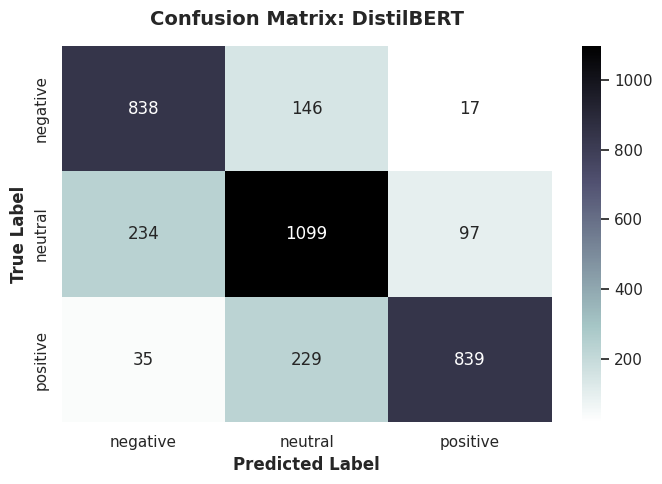

In [18]:
cm = confusion_matrix(y_test, bert_test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='bone_r',
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 12})
plt.title("Confusion Matrix: DistilBERT", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("True Label", fontweight='bold')
plt.xlabel("Predicted Label", fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4. Qualitative Error Analysis (DistilBERT)

In [19]:
misclassified_df = get_misclassified_examples(
    y_true=y_test,
    y_pred=bert_test_preds,
    raw_texts=df_test['text'],
    label_encoder=le,
    num_examples=25
)

display(misclassified_df)

,Text,True_Label,Predicted_Label
7,"soooooo wish i could, but im in school and myspace is completely blocked",negative,neutral
19,"I`m going into a spiritual stagnentation, its exploding my ego!. I now realise, i`m not all that great. and I`m ok with that.",neutral,negative
26,"hey peoples, dont you just hate being grounded haha, im just sat eating an apple and watching death note (some anime)",neutral,negative
28,look who I found just for you ---> http://twitter.com/DJT2009,positive,neutral
37,So I really need to put the laptop down & start getting ready for shindig...But I`ve missed my TwitterLoves all day,neutral,negative
41,I always forget SOMETHING when I travel. I am at Newark airport.,neutral,negative
50,Is watching acoustic performances! & In the mood for a good 'FRIENDS' episode! I miss that show,neutral,negative
64,at starbucks with my love. eff school. i have work later too.,neutral,positive
66,"Hi all, just recovering from a party, looking forward to an exciting bank holiday around the diy shops...life cant get much better.surely",positive,neutral
67,Terminator Salvation... by myself.,neutral,positive
